# Annual station climate

NOAA's Global Summary of the Year (GSOY) condenses each land station's daily
GHCN-Daily record into one row per calendar year: annual precipitation, mean
temperature, extremes, and counts of days past thresholds. NCEI publishes it
through its Access Data Service, and one request returns one CSV with a row
per station and year.

This walkthrough pulls thirty years of precipitation and mean temperature at
Will Rogers World Airport in Oklahoma City, 1995 to 2024. It needs
`usdata[pandas]` and matplotlib, and runs in a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-25T15:36:07+00:00
usdata 0.27.0; pandas 3.0.6


## Select

The manifest names one station, two variables, and a window. GSOY selects
every UTC calendar year the window touches, in full: 6 May 2024 alone would
select all of 2024, and 31 December to 1 January selects both years.
`units: metric` asks for millimetres and degrees Celsius.

In [2]:
print(manifest.read_text())

name: okc-annual-climate
sources:
  - dataset: noaa:gsoy
    start: 1995-01-01
    end: 2024-12-31
    variables: [PRCP, TAVG]
    params:
      stations: USW00013967
      units: metric



## What arrives

The first pull downloads one CSV and writes `dataset.lock.json` beside the
manifest, pinning the file's checksum. Later pulls reuse the pin and the cache.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: global-summary-of-the-year_1995-01-01_2024-12-31_03f41df5d7f1.csv
Bytes: 2081
Source: https://www.ncei.noaa.gov/access/services/data/v1?dataset=global-summary-of-the-year&stations=USW00013967&startDate=1995-01-01&endDate=2024-12-31&format=csv&units=metric&includeStationLocation=1&dataTypes=PRCP%2CTAVG
Retrieved (UTC): 2026-09-25T15:36:08+00:00
Checksum: sha256:2126a4daf23ff145cc4cb6703d65c676c0664222bce63ee9673f2d203ea82cfd


## Open

The generic CSV reader returns a DataFrame. `DATE` is a four-digit year label;
reading it as text keeps it a label rather than a number. `PRCP` is the annual
total in millimetres and `TAVG` the annual mean in degrees Celsius. NCEI's CSV
has no units row, so the units come from the request.

In [4]:
frame = item.open_csv(dtype={"DATE": "string"})
frame["YEAR"] = frame["DATE"].astype(int)
print(f"{len(frame)} rows, {frame['YEAR'].min()} to {frame['YEAR'].max()}")
frame[["STATION", "DATE", "PRCP", "TAVG"]].tail()

30 rows, 1995 to 2024


,STATION,DATE,PRCP,TAVG
25,USW00013967,2020,979.8,15.8
26,USW00013967,2021,803.2,15.9
27,USW00013967,2022,667.9,16.1
28,USW00013967,2023,947.9,16.7
29,USW00013967,2024,942.4,17.4


## A first look

Thirty annual totals and means, with the thirty-year average of each drawn
across.

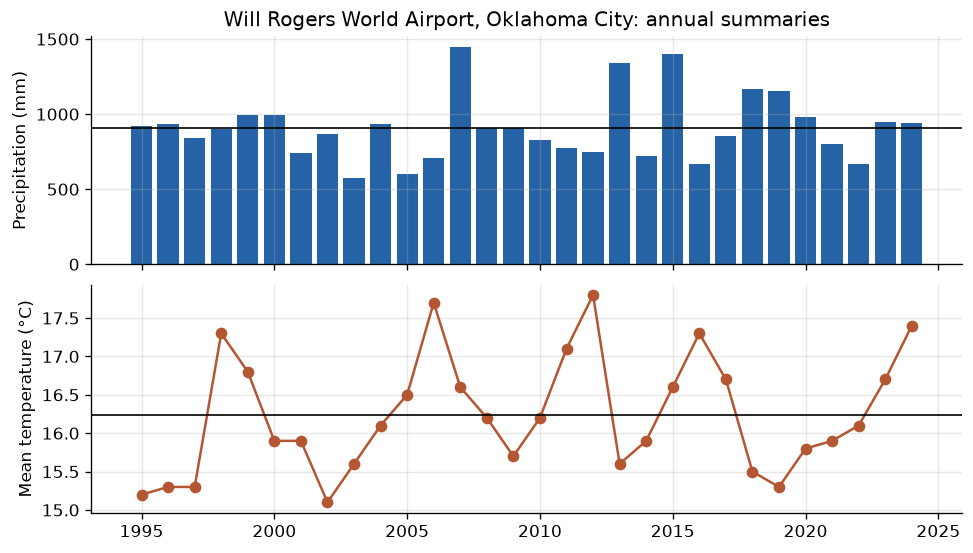

In [5]:
fig, (wet, warm) = plt.subplots(2, 1, sharex=True, layout="constrained")
wet.bar(frame["YEAR"], frame["PRCP"], color="#2563a6")
wet.axhline(frame["PRCP"].mean(), color="black", linewidth=1)
wet.set_ylabel("Precipitation (mm)")
wet.set_title("Will Rogers World Airport, Oklahoma City: annual summaries")
warm.plot(frame["YEAR"], frame["TAVG"], marker="o", color="#b45631")
warm.axhline(frame["TAVG"].mean(), color="black", linewidth=1)
warm.set_ylabel("Mean temperature (°C)")
plt.show()

In [6]:
wettest = frame.loc[frame["PRCP"].idxmax()]
driest = frame.loc[frame["PRCP"].idxmin()]
print(f"Wettest: {wettest['DATE']} with {wettest['PRCP']:.0f} mm")
print(f"Driest: {driest['DATE']} with {driest['PRCP']:.0f} mm")
print(f"Mean temperature ranged {frame['TAVG'].min():.1f} to {frame['TAVG'].max():.1f} °C")

Wettest: 2007 with 1447 mm
Driest: 2003 with 575 mm
Mean temperature ranged 15.1 to 17.8 °C


Year-to-year precipitation varies far more than mean temperature. One
station's thirty years describe that airport's record, not a regional trend.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:gsoy
  Lawrimore, Jay H.; Ray, Ron; Applequist, Scott; Korzeniewski, Bryant; Menne, Matthew J. (2016): Global Summary of the Year (GSOY), Version 1. NOAA National Centers for Environmental Information. https://doi.org/10.7289/JWPF-Y430
  homepage: https://www.ncei.noaa.gov/access/search/data-search/global-summary-of-the-year
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00947/html
  retrieved: 2026-09-25; 1 checksummed asset (2,081 bytes) pinned by usdata 0.27.0
  sources: 1


## What was awkward

- `DATE` looks like a number, so pandas reads it as one unless told
  otherwise; `dtype={"DATE": "string"}` keeps the year a label.
- The CSV carries no units. The request's `units: metric` used to be the only
  record of whether `PRCP` is millimetres or inches; the frame now keeps it in
  `attrs["usdata"]["properties"]`.
- Annual labels hide different accumulation seasons for some elements; the
  [GSOY guide](https://docs.usdata.dev/providers/noaa-gsoy/) says which.